# 🎯 Meningioma cut-points

Run from the repo root, after `meningioma-cleaning.ipynb`.

One question, asked in fifteen small steps: **for each MRI measurement, is there a threshold — and can we defend it?**

| | Step | Asks |
|---|---|---|
| **What have we got** | 1 | Load the cohort |
| | 2 | How are the five measurements spread, and what is missing? |
| **Is anything here** | 3 | Does each measurement separate grade 1 from grade 2–3? |
| **Is a threshold real** | 4 | Does risk climb smoothly, or is there a genuine bend? |
| | 5 | If there is a bend — where? |
| **Pick the number** | 6 | Five ways to choose a cut-point. Do they agree? |
| | 7 | How much does it wobble with different patients? |
| | 8 | Do the missing ADC values move it? |
| **What it costs** | 9 | Cut-point vs the raw number — the price of dichotomising |
| | 10 | All ten side by side, ranked |
| **Worth using** | 11 | Five cut-offs together vs five raw numbers together |
| | 12 | The evidence table — every criterion, met or not |
| | 13 | Where does the break actually sit? |
| **Worth acting on** | 14 | Would a doctor who followed the rule be better off? |
| **Write it up** | 15 | Tables, figures, proof sheet and manifest |

Then: tables (`.docx`), figures (`.tif` + `.png`), one `.html` with all of it, and a `manifest.json` recording what produced them.

## Step 1 — Load the data

Reads the **unimputed** cohort — the values that were actually measured. Steps 2–7 answer their questions on those; the 20 filled-in versions come back at step 8 to show what the missing ADC scans cost.

Duplicate patients are not re-checked here — the cleaning notebook already audited them at §04 and found none.

One thing *is* asserted: every patient must have a grade. A missing grade is not a missing measurement, it is a patient who cannot be scored at all — and dropping those quietly later would change the denominator between one table and the next.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

# ⚙️ Import config first — it puts cutpoint_phase/ on sys.path so the flat
#    sibling imports below resolve.
from heavy_machinery.config import load  # noqa: F401

import loading as ld

pd.set_option("display.max_columns", None)

OUTPUT_ROOT = Path("output")

df = ld.load_cohort(OUTPUT_ROOT)
ld.check_outcome_complete(df)   # raises if any patient has no WHO grade

FACTS = ld.cohort_facts(df)
print(ld.describe(FACTS))

352 patients — 105 high grade (WHO 2-3), 247 low grade (WHO 1), 29.8% high grade.


## Step 2 — The five measurements: how they spread, what is missing

Each measurement is **declared**, not guessed. Four things are written down for each one:

- **Direction** — which way it points at high grade. ADC points *down* (low ADC is suspicious); the other four point *up*. This is declared rather than read off the data, because a computer asked to work out the direction will always pick whichever one makes the measurement look good — turning a genuine "this doesn't work" into a weak-looking positive.
- **Log-transformed?** — three of the five are heavily lopsided: most tumours are small, a few are enormous. Working on the log scale stops those few giants dominating everything.
- **Decimals** — the precision the paper prints, fixed once so a number can't be rounded one way in a table and another in a figure.
- **Unit** — written twice, plain for tables and mathtext for figure axes, because the same string can't do both.

*Median and IQR* below, not mean ± SD. **Median** = the middle patient. **IQR** (interquartile range) = the middle half of patients, from the 25th to the 75th. For lopsided measurements an average sits above most of the cohort and misleads.

**`pct_zero` is the column to watch.** Where a lot of patients sit at exactly zero, a cut-point stops measuring *how much* and starts measuring *whether there is any at all* — a different claim, which the paper has to state plainly rather than let the reader assume.

In [2]:
import measurements as ms

ms.validate(ms.MEASUREMENTS, df)   # raises on a bad direction or absent column

SPREAD = ms.spread_table(df)
print(ms.describe_missing(SPREAD))
print(ms.describe_zeros(SPREAD))

# Does the data still agree with how each measurement is declared?
for note in ms.check_zero_declarations(df):
    print(f"⚠️  {note}")

SPREAD

ADC (mean) is missing for 43 patients (12.2%) — the widest gap; then Edema index 29, Tumor volume 23, Edema volume 19. Complete for every patient: Max diameter.
Patients sitting at exactly zero — Edema volume 122/333 (36.6%); Edema index 113/323 (35.0%). These are analysed twice: across all patients (presence and amount together) and among those above zero (amount alone).


,measurement,unit,direction,n_observed,n_missing,pct_missing,n_zero,pct_zero,median,iqr_low,iqr_high,min,max,log_transformed
0,ADC (mean),×10⁻³ mm²/s,≤ cut-point flags high grade,309,43,12.2,0,0.0,0.820,0.75,0.9200,0.41,1.7000,False
1,Tumor volume,cm³,≥ cut-point flags high grade,329,23,6.5,0,0.0,14.700,5.10,36.5000,0.30,168.0000,True
2,Edema volume,cm³,≥ cut-point flags high grade,333,19,5.4,122,36.6,4.480,0.00,29.2000,0.00,197.0000,True
3,Edema index,,≥ cut-point flags high grade,323,29,8.2,113,35.0,0.221,0.00,1.1196,0.00,39.4258,True
4,Max diameter,cm,≥ cut-point flags high grade,352,0,0.0,0,0.0,3.800,2.80,5.3000,0.20,9.2000,False


### Step 2b — Splitting the edema question in two

More than a third of patients have **no edema at all**. Asked of everyone, "does edema volume predict high grade?" is quietly two questions stacked on top of each other:

1. **Does *having* edema matter?** — presence vs absence
2. **Among patients who have edema, does *how much* matter?** — magnitude given presence

They can even point opposite ways, and one cut-point cannot tell them apart. So the two edema measurements are analysed in **two strata** from here on:

| Stratum | Who's in it | What it answers |
|---|---|---|
| `all` | everyone measured | presence and amount together |
| `present` | only patients above zero | amount alone, presence held constant |

The other three measurements have no pile at zero, so they get one stratum and nothing changes for them.

Patients whose edema was never measured are in **neither** stratum — "we didn't look" is not the same finding as "we looked and there was none", and merging them would pad the absent group with patients nobody assessed.

In [3]:
PRESENCE = ms.presence_table(df)
PRESENCE

,measurement,n_observed,n_absent,n_present,pct_present
0,Edema volume,333,122,211,63.4
1,Edema index,323,113,210,65.0


## Step 3 — Does each measurement separate the grades at all?

Before drawing any line, ask whether there is anything to draw a line through.

**AUC** (area under the ROC curve) answers it in one number. Pick one high-grade patient and one low-grade patient at random. How often is the high-grade one on the suspicious side of the measurement?

- **0.50** = a coin flip. The measurement carries no information.
- **1.00** = perfect. Every high-grade patient is on the suspicious side.
- **0.70** is generally considered modest; **0.80** good.

The interval comes from **DeLong** — a closed formula rather than resampling, so it gives the same answer every run and it also produces the pieces needed to compare two AUCs later (step 10).

**The number to read is `auc_lo`, the lower end.** If it sits at or below 0.50, the measurement has *not* been shown to separate the grades — and no cut-point drawn on it can be defended, however good the middle number looks.

Direction is applied here, not discovered: ADC is flipped before scoring, because low ADC is the suspicious side. If the code were allowed to pick the orientation itself, every AUC would come out at 0.50 or above and a genuine "this does nothing" would be dressed up as a weak positive.

In [4]:
import separation as sep

SEPARATION = sep.separation_table(df)
print(sep.describe_separation(SEPARATION))

SEPARATION[["measurement", "n", "n_high", "n_low",
            "auc", "auc_lo", "auc_hi"]].round(3)

Best separation: Tumor volume, AUC 0.68 (95% CI 0.61-0.74), n=329. Clearing 0.50 at the lower bound: Tumor volume, Max diameter, Edema volume, ADC (mean), Edema index (5 of 7).


,measurement,n,n_high,n_low,auc,auc_lo,auc_hi
0,Tumor volume,329,101,228,0.679,0.613,0.738
1,Max diameter,352,105,247,0.675,0.611,0.733
2,Edema volume,333,99,234,0.629,0.564,0.690
3,ADC (mean),309,96,213,0.627,0.555,0.694
4,Edema index,323,98,225,0.577,0.512,0.639
5,Edema volume (where present),211,76,135,0.576,0.497,0.652
6,Edema index (where present),210,76,134,0.471,0.394,0.551


### Step 3b — Is the edema signal presence, or amount?

An AUC cannot score a yes/no predictor — there is no ranking to measure. So presence is scored the direct way: the high-grade rate among patients with no edema, against the rate among patients with some, each with its interval.

Read this table together with the two `(where present)` rows above. If presence separates the grades but amount-given-presence does not, then an edema **cut-point** is really a rebadged **presence test**, and the paper should say so rather than quote a volume in cm³ as though the number mattered.

In [5]:
PRESENCE_EFFECT = sep.presence_table(df)
PRESENCE_EFFECT.round(3)

,measurement,n_absent,high_grade_absent,rate_absent,rate_absent_lo,rate_absent_hi,n_present,high_grade_present,rate_present,rate_present_lo,rate_present_hi,rate_difference
0,Edema volume,122,23,0.189,0.129,0.267,211,76,0.360,0.298,0.427,0.172
1,Edema index,113,22,0.195,0.132,0.277,210,76,0.362,0.300,0.429,0.167


## Step 4 — Is a threshold even real?

This is the biological question. A threshold only means something if risk **changes character** somewhere. If risk rises steadily all the way across, then any line you draw is an administrative convenience — useful, perhaps, but not a boundary in the biology, and the paper must not present it as one.

Two models are fitted and compared:

| | Shape | What it says |
|---|---|---|
| **straight** | one steady climb | more is worse, at a constant rate |
| **bent** | a *restricted cubic spline* | three straight pieces joined smoothly, with the tails forced straight |

A **spline** is just a flexible curve: it lets the relationship bend at a few chosen points (**knots**) instead of forcing a single straight line. *Restricted* means the two ends are held straight, so the curve can't fly off where there are few patients.

The knots sit at the 10th, 50th and 90th percentile of patients — **where the patients are**, not evenly along the axis.

Because the bent model contains the straight one, we can ask whether the extra flexibility earned its keep. That's the **likelihood-ratio test**: a small P value means the bend explains enough extra to be worth having; a large P means the straight line already said everything.

### ⚠️ The catch: "bent" depends on what you plot it against

Whether a curve looks bent is not a property of the biology alone — it depends on the scale. The same patients can look bent against volume in cm³ and perfectly straight against log-volume.

So the **primary test runs in clinical units** (cm³, ADC units, cm) — the scale the cut-point is quoted in. Testing on one scale and quoting a cut-point on another would be incoherent. The log-scale fit runs alongside as a **sensitivity check**, so where the two disagree you can see it rather than have a scale silently chosen for you.

**Read `scales_agree`.** Where it is `False`, no claim about a bend is scale-free, and that has to be reported rather than resolved in favour of the nicer answer.

In [6]:
import nonlinearity as nl

# One fit per measurement per stratum per scale — step 5 reads the curves
# off these, so nothing is fitted twice.
FITS = nl.fit_all(df)

NONLINEARITY = nl.nonlinearity_table(df, fits=FITS)
print(nl.describe_nonlinearity(NONLINEARITY))

NONLINEARITY[["measurement", "n", "n_knots", "lr_stat", "lr_df", "lr_p",
              "bent_clinical", "lr_p_log", "bent_log", "scales_agree"]].round(4)

Bend detected in clinical units: ADC (mean) (P=0.009), Tumor volume (P=0.021), Edema volume (P=0.007), Edema index (P=0.047). Scale-dependent, so no claim about a bend is scale-free: Tumor volume, Edema volume.


,measurement,n,n_knots,lr_stat,lr_df,lr_p,bent_clinical,lr_p_log,bent_log,scales_agree
0,ADC (mean),309,3,6.7554,1,0.0093,True,0.0153,True,True
1,Tumor volume,329,3,5.3296,1,0.0210,True,0.9738,False,False
2,Edema volume,333,3,7.1843,1,0.0074,True,0.1587,False,False
3,Edema volume (where present),211,3,1.7957,1,0.1802,False,0.1249,False,True
4,Edema index,323,3,3.9350,1,0.0473,True,0.0019,True,True
5,Edema index (where present),210,3,0.1763,1,0.6746,False,0.3312,False,True
6,Max diameter,352,3,0.4490,1,0.5028,False,0.7730,False,True


## Step 5 — Where is the bend?

Step 4 asked *whether* the climb changes character. This asks *where* — and answers it two ways, because they are different clinical questions.

**The knee** (`knee`) — the value at which risk is climbing **fastest**. The dose-response answer: where one more cm³ buys the most extra risk.

**The risk crossings** (`risk_30`, `risk_50`) — the value at which predicted risk reaches **30%** or **50%**. The counselling answer: *"above this number, one patient in two is high grade."* This doesn't care about the curve's shape, only where it passes a line that matters to a clinician.

### Two guards before quoting either number

**A steepest point exists on every curve — including a perfectly straight one.** On a straight line it's just wherever the arithmetic happened to wobble, and it means nothing. So `bend_is_real` (step 4's verdict) is carried into this table, and a knee is only quotable when the bend survived the test.

**A knee at the edge of the data is an artefact.** Splines are least reliable at their ends. But "edge" is judged in **patients**, not axis units — edema volume runs to 197 cm³ while half the cohort sits below 4.5, so a knee at 3.5 cm³ is 2% along the axis but at the **48th percentile of patients**. Judging by axis position would throw away a knee sitting right in the middle of the data. That's what `knee_percentile` reports.

**`quotable` = the bend was real **and** the knee isn't at the edge.**

⏳ No interval on the knee yet — that's step 7, which re-derives it in 2,000 resampled cohorts. A knee whose interval spans most of the observed range is not a landmark, however precise this point estimate looks.

In [7]:
import bend_location as bl

BEND = bl.bend_table(df, fits=FITS)   # reuses step 4's fits — nothing refitted
print(bl.describe_bend(BEND))

BEND[["measurement", "n", "bend_is_real", "scales_agree", "knee", "knee_risk",
      "knee_percentile", "knee_at_boundary", "risk_30", "risk_50",
      "quotable"]].round(4)

Knees that may be quoted — ADC (mean) ≤ 0.66 ×10⁻³ mm²/s; Tumor volume ≥ 12.7 cm³ (scale-dependent); Edema volume ≥ 3.51 cm³ (scale-dependent); Edema index ≥ 0.0915. 3 of 7 withheld: no bend, or a bend sitting at the edge of the data.


,measurement,n,bend_is_real,scales_agree,knee,knee_risk,knee_percentile,knee_at_boundary,risk_30,risk_50,quotable
0,ADC (mean),309,True,True,0.6619,0.5021,7.1197,False,0.7913,0.6631,True
1,Tumor volume,329,True,False,12.7176,0.2495,46.8085,False,18.5193,62.2617,True
2,Edema volume,333,True,False,3.5126,0.2430,47.7477,False,9.9225,NaN,True
3,Edema volume (where present),211,False,True,7.7382,0.3118,29.3839,False,5.3320,NaN,False
4,Edema index,323,True,True,0.0915,0.2699,40.8669,False,0.3833,NaN,True
5,Edema index (where present),210,False,True,10.6441,0.2971,97.1429,True,0.0231,NaN,False
6,Max diameter,352,False,True,3.5578,0.2604,46.0227,False,4.0418,6.8187,False


### Step 5c — What carries into cut-point derivation, and as what

Two questions have now been asked of every measurement, and **they fail independently**:

- **Does it separate the grades?** (step 3) — if the AUC interval includes 0.50, nothing has been shown. There is nothing to cut. It stops here.
- **Does risk bend?** (steps 4–5) — if not, there is no biological boundary. But a measurement can separate the grades perfectly well without having one; risk just rises the whole way.

Confusing those two is how a paper overclaims. A measurement with no bend still earns a cut-point — it earns a **different sentence**:

| Claim | Means |
|---|---|
| **threshold** | Real bend, inside the data, on both scales. The number marks a change in the biology. |
| **threshold (scale-dependent)** | Bends in clinical units but not on the log scale. Quotable — the caveat travels with it. |
| **operating point** | No bend. A chosen place to stand on a smooth slope, the way *"hypertension starts at 140/90"* is a convention, not a cliff. Fully reportable, never called a threshold. |

The claim is decided **once**, here, and carried into every downstream table — so the wording can't drift between a figure caption and the Results text.

Rows that stop here stay in the table with their reason. A measurement that was tested and dropped is a result; silently omitting it would leave a reader unable to tell testing from selective reporting.

In [8]:
import eligibility as el

ELIGIBILITY = el.carry_forward(SEPARATION, BEND)
print(el.describe_eligibility(ELIGIBILITY))

ELIGIBLE = el.eligible(ELIGIBILITY)   # what step 6 derives cut-points for

ELIGIBILITY[["measurement", "n", "auc", "auc_lo", "separates", "bend_is_real",
             "knee_quotable", "scales_agree", "carries_forward",
             "claim", "reason"]].round(3)

Carried into cut-point derivation — operating point: Max diameter; threshold: ADC (mean), Edema index; threshold (scale-dependent): Tumor volume, Edema volume. Stops here: Edema volume (where present), Edema index (where present) (interval includes 0.50).


,measurement,n,auc,auc_lo,separates,bend_is_real,knee_quotable,scales_agree,carries_forward,claim,reason
0,Tumor volume,329,0.679,0.613,True,True,True,False,True,threshold (scale-dependent),bends in clinical units but not on the log sca...
1,Max diameter,352,0.675,0.611,True,False,False,True,True,operating point,"separates the grades, but risk climbs smoothly..."
2,Edema volume,333,0.629,0.564,True,True,True,False,True,threshold (scale-dependent),bends in clinical units but not on the log sca...
3,ADC (mean),309,0.627,0.555,True,True,True,True,True,threshold,"bends on both scales, inside the data — the nu..."
4,Edema index,323,0.577,0.512,True,True,True,True,True,threshold,"bends on both scales, inside the data — the nu..."
5,Edema volume (where present),211,0.576,0.497,False,False,False,True,False,,interval includes 0.50 — no separation shown
6,Edema index (where present),210,0.471,0.394,False,False,False,True,False,,interval includes 0.50 — no separation shown


## Step 6 — Five ways to choose a cut-point. Do they agree?

There is no single correct cut-point. There are only **rules** for picking one, and each rule optimises something different.

| Rule | Picks | Pre-specifiable? |
|---|---|---|
| **Youden** | max `Se + Sp − 1` — treats a missed tumour and a false alarm as equally costly | ❌ |
| **Closest to perfect** | the point nearest the top-left corner of the ROC curve | ❌ |
| **Index of union** | where Se and Sp both sit closest to the overall AUC | ❌ |
| **Specificity ≥ 90%** | catch the most cases while keeping false alarms low — **rule-in** | ✅ |
| **Specificity ≥ 80%** | same, one notch looser | ✅ |
| **Sensitivity ≥ 90%** | catch 90% of tumours, accept the false alarms — **rule-out** | ✅ |

**Pre-specifiable** matters: those three can be stated *before* looking at the data, they don't depend on how common high grade is here, and they transfer to another hospital. Youden can claim none of that — it was picked *because* it looked best on these patients, which is why step 7 exists.

### Two terms

**LR+** (positive likelihood ratio) — how many times more likely a positive result is in a high-grade patient than a low-grade one. It does **not** depend on how common high grade is, so it transfers. Above 10 is strong, around 5 moderate, below 2 barely worth acting on.

**PPV / NPV** — the question a clinician actually asks (*"this scan is positive, what's the chance it's high grade?"*). But these **do** depend on how common high grade is. This is a surgical series at ~30%; in an unselected imaging population the rate is far lower and PPV would fall with it. Reported here as descriptions of *this* cohort — not transferable.

### `usable` — the column that stops a broken rule reaching the paper

A rule can be *satisfied* and still produce something nobody should apply:
- **flags everyone** — on a measurement where a third of patients sit at exactly zero, "sensitivity ≥ 90%" is met by a cut-point of 0, which flags the whole cohort and has zero specificity
- **anti-predictive** — Youden J at or below zero, or LR+ below 1, meaning a positive result argues *against* high grade

In [9]:
import criteria as cr

CRITERIA = cr.criteria_table(df, ELIGIBLE)

CRITERIA[["measurement", "claim", "criterion_label", "pre_specified",
          "cutoff_rounded", "sensitivity", "specificity", "ppv", "npv",
          "lr_pos", "youden_j", "n", "usable", "unusable_because"]].round(3)

,measurement,claim,criterion_label,pre_specified,cutoff_rounded,sensitivity,specificity,ppv,npv,lr_pos,youden_j,n,usable,unusable_because
0,Tumor volume,threshold (scale-dependent),Youden (max Se + Sp − 1),False,15.100,0.673,0.601,0.428,0.806,1.687,0.274,329,True,
1,Tumor volume,threshold (scale-dependent),Closest to perfect,False,16.400,0.653,0.618,0.431,0.801,1.713,0.272,329,True,
2,Tumor volume,threshold (scale-dependent),Se = Sp crossing,False,17.400,0.624,0.623,0.423,0.789,1.654,0.247,329,True,
3,Tumor volume,threshold (scale-dependent),Specificity ≥ 90%,True,61.400,0.267,0.904,0.551,0.736,2.770,0.171,329,True,
4,Tumor volume,threshold (scale-dependent),Specificity ≥ 80%,True,34.800,0.446,0.811,0.511,0.768,2.362,0.257,329,True,
5,Tumor volume,threshold (scale-dependent),Sensitivity ≥ 90%,True,4.500,0.901,0.272,0.354,0.861,1.238,0.173,329,True,
6,Tumor volume,threshold (scale-dependent),Index of union,False,15.100,0.673,0.601,0.428,0.806,1.687,0.274,329,True,
7,Max diameter,operating point,Youden (max Se + Sp − 1),False,3.810,0.686,0.599,0.421,0.818,1.711,0.285,352,True,
8,Max diameter,operating point,Closest to perfect,False,3.810,0.686,0.599,0.421,0.818,1.711,0.285,352,True,
9,Max diameter,operating point,Se = Sp crossing,False,4.100,0.629,0.628,0.418,0.799,1.688,0.256,352,True,


### Step 6b — How tightly do the rules agree?

Only the **three optimum-seeking rules** count here — Youden, closest-to-perfect, index-of-union. All three are trying to answer the *same* question ("where is the best single dividing line?") by different arithmetic, so if they land close together that is real evidence the cut-point belongs to the data rather than to the rule.

The fixed-Se and fixed-Sp rules are deliberately standing at **opposite ends** of the curve. They answer a different question — *"where do I want to stand?"* — so including them would guarantee a wide band whatever the data say, and would hide genuine agreement among the rules that are comparable.

**`spread_vs_iqr`** divides the band width by the middle half of the measurement's own distribution, so it can be compared across measurements in different units.

- **below ~0.5** → the rules are picking essentially the same place
- **above 1** → they disagree by more than the spread of a typical patient, and no single number deserves to be called *the* cut-point

In [10]:
AGREEMENT = cr.agreement(CRITERIA, df)
print(cr.describe_agreement(AGREEMENT))

AGREEMENT[["measurement", "claim", "n_criteria", "n_unusable", "cutoff_min",
           "cutoff_median", "cutoff_max", "spread", "iqr",
           "spread_vs_iqr"]].round(4)

Rules land in a narrow band — Tumor volume 15.1-17.4; Max diameter 3.81-4.1; Edema volume 4.76-7.4; ADC (mean) 0.72-0.81; Edema index 0.0617-0.3047.


,measurement,claim,n_criteria,n_unusable,cutoff_min,cutoff_median,cutoff_max,spread,iqr,spread_vs_iqr
0,Tumor volume,threshold (scale-dependent),4,0,15.1000,15.8000,17.4000,2.300,31.4200,0.0732
1,Max diameter,operating point,4,0,3.8100,3.8600,4.1000,0.290,2.5000,0.1160
2,Edema volume,threshold (scale-dependent),4,1,4.7600,5.5400,7.4000,2.640,29.2000,0.0904
3,ADC (mean),threshold,4,0,0.7200,0.7900,0.8100,0.090,0.1700,0.5294
4,Edema index,threshold,4,3,0.0617,0.2269,0.3047,0.243,1.1196,0.2171


## Step 7 — How much would the cut-point move with different patients?

A cut-point found by trying every candidate and keeping the best is **optimistically biased**. It was chosen *because* it looked good on these 352 patients, and some of how good it looked was luck. Two things follow, and this step measures both.

### The cut-point gets its own confidence interval

Not its sensitivity — the **number itself**. Draw a pretend cohort of 352 patients out of the real one (with replacement, so some appear twice and some not at all), and **re-derive the cut-point from scratch** inside it. Do that 1,000 times. The middle 95% of those values is the interval.

Re-deriving is the whole point. Testing one *fixed* cut-point across resamples measures how stable its performance is — not how stable **the number** is, and the number is what the paper prints.

### Performance shrinks when the cut-point meets new patients

Each resample leaves some patients out of the bag. Derive the cut-point on the patients who were drawn, then score it on the ones held out:

```
optimism = J on the patients it learned from − J on the patients held out
```

Subtract that and you get what to expect at **another hospital**. `j_corrected` is the honest number.

### `stability_ratio` — the column that decides the wording

Interval width ÷ the middle half of the measurement's own spread.

- **below 1** → the interval is tighter than the ordinary variation between patients. The number locates something.
- **above 1** → the cut-point could be anywhere across the typical patient's range. It's a coin flip dressed as a number, and the paper must say so.

🔒 The five published cut-points are **frozen**. This step produces intervals only — if the bootstrap ever re-derived a different point estimate, the run stops with an error rather than quietly rewriting a number the manuscript already prints.

Seed `20260801`, shared with the modelling-phase bootstraps so the two stay in step.

In [11]:
import wobble as wb

# The five numbers the manuscript already prints. The bootstrap may bracket
# them; if it ever re-derives a different one, the run stops.
FROZEN_CUTPOINTS = {
    "adc_value": 0.72,
    "max_diameter_cm": 3.81,
    "tumor_volume": 15.1,
    "edema_volume_cm3": 4.76,
    "edema_index": 0.0617,
}

WOBBLE, WOBBLE_DRAWS = wb.wobble_table(
    df, ELIGIBLE, n_boot=wb.N_BOOTSTRAP, seed=wb.SEED, frozen=FROZEN_CUTPOINTS)
print(wb.describe_wobble(WOBBLE))

WOBBLE[["measurement", "claim", "cutpoint", "ci_lo", "ci_hi",
        "ci_width", "measurement_iqr", "stability_ratio",
        "j_apparent", "optimism", "j_corrected",
        "n_valid", "n_skipped"]].round(4)

Holds up under resampling — Max diameter 3.81 (3.3-5.7); Edema volume 4.76 (1.53-13.3); ADC (mean) 0.72 (0.69-0.85); Edema index 0.0617 (0.0433-0.1749). Interval wider than the measurement's own middle half, so the number is not a landmark — Tumor volume 15.1 (6.8-44.8, 1.2x its IQR).


,measurement,claim,cutpoint,ci_lo,ci_hi,ci_width,measurement_iqr,stability_ratio,j_apparent,optimism,j_corrected,n_valid,n_skipped
0,Tumor volume,threshold (scale-dependent),15.1000,6.8000,44.8000,38.0200,31.4200,1.2101,0.2741,0.0946,0.1795,1000,0
1,Max diameter,operating point,3.8100,3.3000,5.7000,2.4000,2.5000,0.9600,0.2849,0.0811,0.2038,1000,0
2,Edema volume,threshold (scale-dependent),4.7600,1.5300,13.3000,11.7700,29.2000,0.4031,0.2723,0.0550,0.2173,1000,0
3,ADC (mean),threshold,0.7200,0.6900,0.8500,0.1580,0.1700,0.9294,0.2368,0.0562,0.1806,1000,0
4,Edema index,threshold,0.0617,0.0433,0.1749,0.1315,1.1196,0.1175,0.2275,0.0451,0.1824,1000,0


## Step 8 — Do the scans we never measured move the cut-point?

ADC is missing for **43 patients**, one in eight. Steps 3–7 simply set them aside — which quietly assumes the missing scans would have looked like the ones we have. That assumption is usually wrong in a way that matters: a scan is more often absent because the tumour was small, or the study was old, or the sequence failed. None of those is unrelated to grade.

**Multiple imputation** fills the gaps **twenty different plausible ways**, each guessed from the patient's other columns, then runs everything twenty times. Where the twenty answers agree, the missing scans weren't deciding anything. Where they scatter, they were.

### Two different questions — don't conflate them

| Column | Asks |
|---|---|
| `draw_min` … `draw_max` | *How much does the answer depend on **how we filled the gaps**?* Nothing to do with sampling. |
| `joint_ci_lo` … `joint_ci_hi` | *How much would the number move at **another hospital**, allowing for both different patients **and** differently-filled gaps?* |

The joint interval resamples patients **and** picks one of the twenty imputations at random **in the same replicate**, so both sources of uncertainty land in one number. That's the interval to quote.

A tight joint interval with wide across-draw spread is a **missing-data** story. A wide joint interval with tight agreement is a **sample-size** story. The paper needs to know which it has.

### Why not Rubin's rules

The usual way to pool across imputations averages an estimate and its variance. A cut-point isn't an estimate — it's the **position of a maximum**, and averaging positions can land somewhere no draw actually chose. Median with the full range is the honest summary.

🔒 **`diverges` is a build gate.** If a published cut-point falls outside the range *every* draw produced, that number is an artefact of the complete-case derivation that no imputation reproduces. That's a finding, not a formatting problem, and it has to surface before a table is written rather than after review.

In [12]:
import imputation as imp

DRAWS = imp.load_draws(OUTPUT_ROOT)
print(f"{len(DRAWS)} imputed draws")

# The edema index is a ratio — it must be rebuilt from its two imputed parents
# inside each draw, never imputed on its own.
for note in imp.check_derived_consistency(DRAWS):
    print(f"⚠️  {note}")

IMPUTATION = imp.imputation_table(
    DRAWS, ELIGIBLE, WOBBLE, n_boot=wb.N_BOOTSTRAP, seed=wb.SEED,
    frozen=FROZEN_CUTPOINTS)
print(imp.describe_imputation(IMPUTATION))

IMPUTATION[["measurement", "n_draws", "observed_cutpoint", "draw_median",
            "draw_min", "draw_max", "diverges",
            "patients_ci_lo", "patients_ci_hi",
            "joint_ci_lo", "joint_ci_hi", "widening"]].round(4)

20 imputed draws


Allowing for the missing scans widens the interval most for ADC (mean) (0.16 to 0.21, 1.3x). Widest disagreement between imputations: Tumor volume 15.1-44.4.


,measurement,n_draws,observed_cutpoint,draw_median,draw_min,draw_max,diverges,patients_ci_lo,patients_ci_hi,joint_ci_lo,joint_ci_hi,widening
0,Tumor volume,20,15.1000,15.8000,15.1000,44.4000,False,6.8000,44.8000,6.8000,44.8000,1.0005
1,Max diameter,20,3.8100,3.8100,3.8100,3.8100,False,3.3000,5.7000,3.3000,5.7000,1.0000
2,Edema volume,20,4.7600,4.7600,3.8000,4.7600,False,1.5300,13.3000,1.5300,13.3000,1.0000
3,ADC (mean),20,0.7200,0.7200,0.7200,0.7300,False,0.6900,0.8500,0.7000,0.9100,1.3125
4,Edema index,20,0.0617,0.0617,0.0405,0.0617,False,0.0433,0.1749,0.0227,0.1739,1.1488


## Step 9 — What does the cut-point cost, against the number it replaces?

Turning a measurement into a yes/no answer throws information away. Two patients with ADC 0.71 and 0.30 become **the same patient**. Two with 0.71 and 0.73 land on **opposite sides** of a line neither of them is near.

The question is how much that costs — and whether the convenience is worth it.

### `information_retained` — the column to read

```
(AUC of the yes/no answer − 0.5) ÷ (AUC of the raw number − 0.5)
```

The share of the measurement's discriminating power that survives the cut. **0.75 means a quarter of what the measurement knew was thrown away.** Above 1.00 means dichotomising actually *improved* things — which happens when the real signal is a step rather than a slope.

For a yes/no test the AUC is exactly `(Se + Sp) / 2`, so this comparison is exact, not an approximation. The two are compared with **DeLong on the same patients**: a patient who's easy to classify is easy for both, and treating them as separate studies would overstate the difference.

### ⚠️ The two odds ratios are not comparable as numbers

`or_per_sd` is per 1 standard deviation of the raw number. `or_binary` is for being on the wrong side of the line. **Different scales — never compare them directly.**

They're shown together for one reason: the dichotomised OR usually **looks bigger while describing less**. It's the most common way a threshold paper oversells itself, and seeing both side by side makes it obvious.

Odds ratios use Wald intervals. With 105 events and one predictor at a time, profile likelihood would agree to two decimals — and `or_per_sd_asymmetric` flags any interval lopsided enough that this has stopped being true.

In [13]:
import dichotomy as di

DICHOTOMY = di.dichotomy_table(df, ELIGIBLE, FROZEN_CUTPOINTS)

# The same question split in two for the zero-inflated measurements:
# does having any predict, and does how much predict? Table S3.
PRESENCE_AMOUNT = di.presence_amount_table(df)
print(di.describe_dichotomy(DICHOTOMY))

for note in di.asymmetry_notes(DICHOTOMY):
    print(f"⚠️  {note}")

DICHOTOMY[["measurement", "cutoff", "n", "auc_continuous", "auc_binary",
           "auc_loss", "auc_loss_lo", "auc_loss_hi", "auc_loss_p",
           "information_retained"]].round(4)

Dichotomising costs most in Tumor volume: AUC 0.68 as a number falls to 0.64 as a yes/no answer, keeping 77% of its discriminating power. The loss is statistically significant for: Max diameter, Tumor volume.


,measurement,cutoff,n,auc_continuous,auc_binary,auc_loss,auc_loss_lo,auc_loss_hi,auc_loss_p,information_retained
0,Edema index,0.0617,323,0.5768,0.6087,-0.0319,-0.0662,0.0025,0.0689,1.4148
1,Edema volume,4.7600,333,0.6291,0.6362,-0.0071,-0.0378,0.0236,0.6498,1.0550
2,ADC (mean),0.7200,309,0.6271,0.6184,0.0087,-0.0382,0.0555,0.7170,0.9319
3,Max diameter,3.8100,352,0.6747,0.6425,0.0323,0.0012,0.0634,0.0416,0.8152
4,Tumor volume,15.1000,329,0.6787,0.6371,0.0416,0.0099,0.0733,0.0100,0.7671


In [14]:
DICHOTOMY[["measurement", "log_transformed",
           "or_per_sd", "or_per_sd_lo", "or_per_sd_hi", "or_per_sd_p",
           "or_binary", "or_binary_lo", "or_binary_hi", "or_binary_p"]].round(4)

,measurement,log_transformed,or_per_sd,or_per_sd_lo,or_per_sd_hi,or_per_sd_p,or_binary,or_binary_lo,or_binary_hi,or_binary_p
0,Edema index,True,1.0928,0.8670,1.3774,0.4525,2.6501,1.5602,4.5014,0.0003
1,Edema volume,True,1.6097,1.2645,2.0491,0.0001,3.0981,1.8828,5.0980,0.0000
2,ADC (mean),False,0.6240,0.4674,0.8332,0.0014,4.1239,2.2842,7.4453,0.0000
3,Max diameter,False,1.8556,1.4588,2.3603,0.0000,3.2617,2.0097,5.2937,0.0000
4,Tumor volume,True,1.9597,1.5116,2.5405,0.0000,3.1022,1.8946,5.0796,0.0000


## Step 10 — All ten side by side, ranked

Every version of every measurement on one axis: five raw numbers and five yes/no answers, one row each.

⚠️ **Ranking is not choosing.** Two AUCs a hundredth apart are not meaningfully different in 352 patients, and a table sorted by AUC invites the reader to treat first place as a winner. `n` is on every row for the same reason — one result comes from 309 patients and another from 352, and a rank read without the denominator misleads.

### The two pairs that might be the same thing

Tumour volume and max diameter are both **size**. Edema volume and edema index are both **edema**. Within each pair a reader will reasonably ask whether the paper needs both.

You **cannot** answer that by checking whether the confidence intervals overlap. The two measurements come from the *same patients* — a patient who's easy to classify is easy on both — and overlapping intervals routinely hide a real difference between correlated scores. **DeLong's paired test** is what answers it properly, by working out how much the two scores agree and subtracting that shared agreement from the variance of their difference.

### Only two comparisons, named in advance

There are 45 possible pairs among ten rows. Testing all of them would guarantee something looked significant. These two pairs were declared **before** looking, are corrected together with **Benjamini–Hochberg** (the same procedure the EDA tables use, imported rather than rewritten), and the correction applies to a family of two — not to whatever happened to look interesting.

In [15]:
import ranking as rk

RANKED = rk.ranked_table(df, ELIGIBLE, FROZEN_CUTPOINTS)
PAIRWISE = rk.pairwise_table(df, cutpoints=FROZEN_CUTPOINTS)
print(rk.describe_ranking(RANKED, PAIRWISE))

RANKED[["rank", "label", "form", "n", "n_high",
        "auc", "auc_lo", "auc_hi", "claim"]].round(3)

Best discrimination: Tumor volume (raw number), AUC 0.68 (95% CI 0.61-0.74), n=329. Not distinguishable on these patients, so the paper does not need both — Tumor volume vs Max diameter as raw number; Tumor volume vs Max diameter as cut-point; Edema volume vs Edema index as cut-point. Genuinely different — Edema volume beats Edema index by 0.047.


,rank,label,form,n,n_high,auc,auc_lo,auc_hi,claim
0,1,Tumor volume (raw number),raw number,329,101,0.679,0.613,0.738,threshold (scale-dependent)
1,2,Max diameter (raw number),raw number,352,105,0.675,0.611,0.733,operating point
2,3,Max diameter ≥ 3.81,cut-point,352,105,0.642,0.587,0.695,operating point
3,4,Tumor volume ≥ 15.1,cut-point,329,101,0.637,0.580,0.691,threshold (scale-dependent)
4,5,Edema volume ≥ 4.76,cut-point,333,99,0.636,0.579,0.690,threshold (scale-dependent)
5,6,Edema volume (raw number),raw number,333,99,0.629,0.564,0.690,threshold (scale-dependent)
6,7,ADC (mean) (raw number),raw number,309,96,0.627,0.555,0.694,threshold
7,8,ADC (mean) ≤ 0.72,cut-point,309,96,0.618,0.564,0.670,threshold
8,9,Edema index ≥ 0.0617,cut-point,323,98,0.609,0.554,0.661,threshold
9,10,Edema index (raw number),raw number,323,98,0.577,0.512,0.639,threshold


In [16]:
PAIRWISE[["a", "b", "form", "because", "n_both", "auc_a", "auc_b",
          "difference", "difference_lo", "difference_hi",
          "p", "p_fdr", "distinguishable"]].round(4)

,a,b,form,because,n_both,auc_a,auc_b,difference,difference_lo,difference_hi,p,p_fdr,distinguishable
0,Tumor volume,Max diameter,raw number,both measure size,329,0.6787,0.6734,0.0053,-0.0222,0.0327,0.7079,0.7079,False
1,Tumor volume,Max diameter,cut-point,both measure size,329,0.6371,0.6470,-0.0099,-0.0472,0.0274,0.6030,0.7079,False
2,Edema volume,Edema index,raw number,both measure edema,323,0.6238,0.5768,0.0470,0.0178,0.0763,0.0016,0.0065,True
3,Edema volume,Edema index,cut-point,both measure edema,323,0.6314,0.6087,0.0227,-0.0122,0.0576,0.2019,0.4038,False


### Step 10b — Do the measurements move together?

Step 10 asked whether two measurements carry the same *information about grade*. This asks something more basic: **do they move together at all**, grade aside?

**This is the setup for step 11.** When two predictors rise and fall together, a model can't tell which one is doing the work, so it **splits the effect between them — and both come out looking weak**. That's a *wrong* conclusion, not a null one, and it's the commonest way a multivariable table misleads. A pair flagged here explains a pair of disappointing rows there.

**Spearman, not Pearson.** Spearman correlates the *ranks* — "patient 3 has the 7th largest tumour and the 5th largest diameter" — rather than the values themselves. Three of these measurements are heavily skewed and two have a third of the cohort piled at zero; on that kind of data Pearson mostly reports the influence of a handful of extreme patients. Ranks don't care.

**Every pair gets its own `n`.** Different measurements are missing in different patients, so a single sample size in the caption would be wrong in most cells.

Two things are checked, because they can disagree:

- **`spearman`** — do the raw values move together?
- **`agreement`** — do the two *cut-points* flag the same patients? Two measurements can track each other closely across their whole range while their cut-points sit in different places and select different people. It's the flags, not the values, that a count-based rule would combine.

In [17]:
import collinearity as co

RHO, RHO_N = co.spearman_matrix(df)
PAIRS = co.correlated_pairs(RHO, RHO_N)
FLAG_AGREEMENT = co.flag_agreement(df, FROZEN_CUTPOINTS)
print(co.describe_collinearity(PAIRS, FLAG_AGREEMENT))

display(RHO.round(2))
display(PAIRS.round(3))
FLAG_AGREEMENT[["a", "b", "n_both", "agreement", "phi", "both_flagged",
                "selects_the_same_patients"]].round(3)

Moves together — Tumor volume and Max diameter (0.92, n=329); Edema volume and Edema index (0.91, n=323). A model fitted on both will split their effect and make each look weaker than it is. Cut-points selecting essentially the same patients — Tumor volume ≥ 15.1 and Max diameter ≥ 3.81 (90%); Edema volume ≥ 4.76 and Edema index ≥ 0.0617 (89%).


,ADC (mean),Tumor volume,Edema volume,Edema index,Max diameter
ADC (mean),1.00,-0.22,0.04,0.10,-0.26
Tumor volume,-0.22,1.00,0.51,0.23,0.92
Edema volume,0.04,0.51,1.00,0.91,0.49
Edema index,0.10,0.23,0.91,1.00,0.23
Max diameter,-0.26,0.92,0.49,0.23,1.00


,a,b,n_both,spearman,abs_spearman,moves_together
0,Tumor volume,Max diameter,329,0.916,0.916,True
1,Edema volume,Edema index,323,0.914,0.914,True
2,Tumor volume,Edema volume,323,0.511,0.511,False
3,Edema volume,Max diameter,333,0.492,0.492,False
4,ADC (mean),Max diameter,309,-0.262,0.262,False
5,Tumor volume,Edema index,323,0.234,0.234,False
6,Edema index,Max diameter,323,0.232,0.232,False
7,ADC (mean),Tumor volume,308,-0.222,0.222,False
8,ADC (mean),Edema index,304,0.101,0.101,False
9,ADC (mean),Edema volume,304,0.044,0.044,False


,a,b,n_both,agreement,phi,both_flagged,selects_the_same_patients
0,Tumor volume ≥ 15.1,Max diameter ≥ 3.81,329,0.897,0.793,143,True
1,Edema volume ≥ 4.76,Edema index ≥ 0.0617,323,0.895,0.803,163,True
2,Edema volume ≥ 4.76,Max diameter ≥ 3.81,333,0.721,0.442,115,False
3,Tumor volume ≥ 15.1,Edema volume ≥ 4.76,323,0.697,0.394,111,False
4,Edema index ≥ 0.0617,Max diameter ≥ 3.81,323,0.659,0.335,120,False
5,Tumor volume ≥ 15.1,Edema index ≥ 0.0617,323,0.641,0.297,117,False
6,ADC (mean) ≤ 0.72,Tumor volume ≥ 15.1,308,0.591,0.206,41,False
7,ADC (mean) ≤ 0.72,Max diameter ≥ 3.81,309,0.583,0.197,41,False
8,ADC (mean) ≤ 0.72,Edema volume ≥ 4.76,304,0.530,0.105,37,False
9,ADC (mean) ≤ 0.72,Edema index ≥ 0.0617,304,0.451,0.050,39,False


## Step 11 — All together: cut-offs vs numbers, five vs three

Every earlier step judged one measurement at a time. A radiologist looking at a scan sees all of them at once, so this is the question that decides how the work gets used.

Four models, **all fitted on the same 304 patients** — the ones who have every measurement. Letting the three-predictor model use the extra patients its dropped variables were missing in would let it win on sample size rather than on merit.

### VIF — what step 10b could only predict

**VIF** (variance inflation factor) is how much wider a predictor's confidence interval became *because of the other predictors in the model*. **√VIF is the widening factor directly**: VIF 4 → interval twice as wide.

It answers what the correlation matrix could not. Correlation is pairwise; VIF is all-at-once. Three predictors can each look innocent in pairs while one is nearly reconstructable from the other two.

Above **5** is worth reporting; above **10** the coefficient isn't interpretable. Same thresholds the modelling phase prunes on, so both phases mean the same thing by the word.

### Optimism correction — otherwise the comparison is rigged

A five-predictor model fits the patients it was trained on better than a three-predictor one, **whether or not the extra predictors carry anything**. So each model is refitted in 1,000 resampled cohorts, scored both on the resample it learned from and on the original patients, and the average gap subtracted.

**`auc_corrected` is the only column worth comparing.** Without it, the biggest model always wins.

`epv` (events per variable) is the sanity check — below about 10 a logistic model overfits regardless of how the predictors were chosen.

In [18]:
import models as mo

MODELS, COEFFICIENTS = mo.compare_sets(df, cutpoints=FROZEN_CUTPOINTS)
print(mo.describe_models(MODELS, COEFFICIENTS))

MODELS[["model", "form", "n_predictors", "n", "n_high", "epv",
        "auc_apparent", "optimism", "auc_corrected", "max_vif"]].round(4)

Best after optimism correction: Three cut-points (3 predictors), AUC 0.723 corrected from 0.732, n=304. Worst: Five numbers at 0.685. Spread 0.038. Intervals widened by collinearity — Tumor volume (per 1 SD) in Five numbers (VIF 6.8); Edema volume (per 1 SD) in Five numbers (VIF 5.9); Max diameter (per 1 SD) in Five numbers (VIF 6.1).


,model,form,n_predictors,n,n_high,epv,auc_apparent,optimism,auc_corrected,max_vif
0,Three cut-points,cut-points,3,304,93,31.0,0.7319,0.0092,0.7227,1.2927
1,Five cut-points,cut-points,5,304,93,18.6,0.7318,0.0173,0.7145,3.1422
2,Three numbers,numbers,3,304,93,31.0,0.7013,0.0131,0.6883,1.4326
3,Five numbers,numbers,5,304,93,18.6,0.7085,0.0234,0.6850,6.7585


In [19]:
COEFFICIENTS[["model", "predictor", "or", "or_lo", "or_hi", "p",
              "vif", "vif_flag"]].round(4)

,model,predictor,or,or_lo,or_hi,p,vif,vif_flag
0,Five numbers,ADC (mean) (per 1 SD),0.6547,0.4811,0.8909,0.0070,1.1282,
1,Five numbers,Tumor volume (per 1 SD),1.6086,0.8104,3.1927,0.1741,6.7585,inflated
2,Five numbers,Edema volume (per 1 SD),1.4471,0.7748,2.7027,0.2463,5.9200,inflated
3,Five numbers,Edema index (per 1 SD),0.9364,0.5209,1.6833,0.8262,4.4850,
4,Five numbers,Max diameter (per 1 SD),0.8950,0.4794,1.6708,0.7275,6.0524,inflated
5,Five cut-points,ADC (mean) ≤ 0.72,3.6736,1.9603,6.8844,0.0000,1.0530,
6,Five cut-points,Tumor volume ≥ 15.1,1.0767,0.4528,2.5600,0.8672,2.8327,
7,Five cut-points,Edema volume ≥ 4.76,1.3934,0.5467,3.5514,0.4871,3.1422,
8,Five cut-points,Edema index ≥ 0.0617,1.6417,0.6340,4.2512,0.3072,2.8132,
9,Five cut-points,Max diameter ≥ 3.81,2.0190,0.8243,4.9450,0.1242,3.0164,


## Step 12 — The evidence table

**This is the table that proves the finding, not a figure.**

A ROC curve cannot show that a threshold exists. It shows how well a measurement *ranks* patients — and a smooth, gradual relationship draws exactly the same curve as a sharp step. What settles whether a cut-point deserves publishing is a list of questions, asked of every measurement, each with a stated rule and a number behind it.

Eleven criteria, in three families:

| Family | Criteria | Asks |
|---|---|---|
| **Does it carry signal?** | 1–4 | Is there anything to cut? Does it work as a number? Is it more than a copy of another measurement? Does it hold up next to the others? |
| **Is a threshold real?** | 5–7 | Does risk change character? Does that survive changing the scale? Is the change inside the data or at its edge? |
| **Is the cut-point solid?** | 8–11 | Do different rules agree? Does it survive resampling? Does it survive the missing scans? Does cutting cost much? |

**Rows are criteria, columns are measurements** — each row is one named test with one footnote entry, and you compare measurements by reading across a row.

**No verdict word.** No measurement is labelled *strong* or *fragile*. Those words carry an authority the numbers underneath them don't have, and a reader looking at ten ticks and one cross can judge better than a label can. A test asserts none of those words ever appears in the output.

**Every cell carries its number.** A Yes alone is an assertion; a Yes next to *"AUC 0.627, lower bound 0.555"* is evidence. The long form holds both and belongs in Supplemental Data.

**The footnote is generated from the same objects the arithmetic uses** — it states, for every criterion, the statistic computed and what earns a Yes versus a No. A footnote maintained separately from the code drifts away from it within one revision, and a reader has no way to tell which of the two describes the analysis.

⚠️ **Criteria 2 and 11 must be read together.** A measurement whose *amount* carries no information passes 11 easily — cutting something uninformative costs nothing. Criterion 2 exists to catch exactly that. The footnote says so explicitly.


In [20]:
import scorecard as sc

SCORECARD_LONG = sc.scorecard_long(
    ELIGIBLE,
    separation=SEPARATION, bend=BEND, agreement=AGREEMENT, wobble=WOBBLE,
    imputation=IMPUTATION, dichotomy=DICHOTOMY, pairs=PAIRS,
    coefficients=COEFFICIENTS, adjustment_model="Five cut-points")

SCORECARD = sc.scorecard_wide(SCORECARD_LONG)
print(sc.describe_scorecard(SCORECARD_LONG))
SCORECARD

Most criteria met: Edema index, 6 of 6. It meets every criterion.


measurement,Edema index,ADC (mean),Edema volume,Max diameter,Tumor volume
Criterion,,,,,
5. Nonlinearity,Yes,Yes,Yes,No,Yes
6. Scale invariance,Yes,Yes,No,Yes,No
8. Criterion concordance,Yes,No,Yes,Yes,Yes
9. Sampling stability,Yes,Yes,Yes,Yes,No
10. Imputation stability,Yes,Yes,Yes,Yes,Yes
11. Dichotomisation cost,Yes,Yes,Yes,No,No
Criteria met,6 of 6,5 of 6,5 of 6,4 of 6,3 of 6


In [21]:
# The supplemental form — every Yes/No with the number that decided it,
# plus the formula and the grading rule it was judged against.
import textwrap
print(textwrap.fill(sc.footnote(), 100))

SCORECARD_LONG[["measurement", "criterion_number", "criterion", "family",
                "met", "evidence", "formula", "graded", "step"]]

Note:—Rows are numbered criteria, each graded Yes or No against a stated rule. 5, Nonlinearity:
likelihood-ratio test of a restricted cubic spline (3 knots at the 10th, 50th, 90th percentiles)
against the linear model; χ² = 2(ℓ_spline − ℓ_linear), df = 1. Yes, P below .05; No, P at or above
.05. 6, Scale invariance: the same likelihood-ratio test repeated on log1p(x). Yes, clinical and log
scales reach the same verdict at P = .05; No, the two scales disagree. 8, Criterion concordance:
range of the cut-points chosen by Youden, closest-to-perfect, Se = Sp, and index of union, divided
by the measurement's IQR. Yes, range at or below 0.50 × IQR; No, range above 0.50 × IQR. 9, Sampling
stability: width of the 2.5th–97.5th percentile interval from 1000 patient-level bootstrap
resamples, the cut-point re-derived within each, divided by the measurement's IQR. Yes, width at or
below 1.00 × IQR; No, width above 1.00 × IQR. 10, Imputation stability: cut-point re-derived
independently in each of t

,measurement,criterion_number,criterion,family,met,evidence,formula,graded,step
0,Tumor volume,5,Nonlinearity,Is a threshold real?,True,bend test P 0.021,likelihood-ratio test of a restricted cubic sp...,"Yes, P below .05; No, P at or above .05",4
1,Tumor volume,6,Scale invariance,Is a threshold real?,False,clinical and log scales disagree,the same likelihood-ratio test repeated on log...,"Yes, clinical and log scales reach the same ve...",4
2,Tumor volume,8,Criterion concordance,Is the cut-point solid?,True,"rules span 15.1-17.4, 0.07 of the IQR","range of the cut-points chosen by Youden, clos...","Yes, range at or below 0.50 × IQR; No, range a...",6
3,Tumor volume,9,Sampling stability,Is the cut-point solid?,False,"95% CI 6.8-44.8, 1.21 of the IQR",width of the 2.5th–97.5th percentile interval ...,"Yes, width at or below 1.00 × IQR; No, width a...",7
4,Tumor volume,10,Imputation stability,Is the cut-point solid?,True,imputations span 15.1-44.4,cut-point re-derived independently in each of ...,"Yes, the published cut-point lies inside that ...",8
5,Tumor volume,11,Dichotomisation cost,Is the cut-point solid?,False,77% of discrimination retained,(AUC of the yes/no rule − 0.50) ÷ (AUC of the ...,"Yes, 0.90 or more retained; No, below 0.90 ret...",9
6,Max diameter,5,Nonlinearity,Is a threshold real?,False,bend test P 0.503,likelihood-ratio test of a restricted cubic sp...,"Yes, P below .05; No, P at or above .05",4
7,Max diameter,6,Scale invariance,Is a threshold real?,True,clinical and log scales agree,the same likelihood-ratio test repeated on log...,"Yes, clinical and log scales reach the same ve...",4
8,Max diameter,8,Criterion concordance,Is the cut-point solid?,True,"rules span 3.81-4.1, 0.12 of the IQR","range of the cut-points chosen by Youden, clos...","Yes, range at or below 0.50 × IQR; No, range a...",6
9,Max diameter,9,Sampling stability,Is the cut-point solid?,True,"95% CI 3.3-5.7, 0.96 of the IQR",width of the 2.5th–97.5th percentile interval ...,"Yes, width at or below 1.00 × IQR; No, width a...",7


## Step 13 — Where does the break actually sit?

The spline in step 4 answered *does risk bend*. It cannot answer *where does it break*, because a spline has no break — it curves smoothly, and the "steepest point" is a place on that curve rather than a parameter you can put an interval on.

**Segmented regression** fits the model a threshold claim actually implies: two straight lines meeting at a point.

```
logit(risk) = b0 + b1·x + b2·(x − ψ)⁺
```

**ψ** is the breakpoint — below it the slope is `b1`, above it `b1 + b2`. Unlike the spline's steepest point, ψ is **estimated**, so it gets a confidence interval.

⚠️ **Its P value is not an ordinary likelihood-ratio test.** If there is no break, `b2` is zero — and when `b2` is zero, ψ has no effect on the model at all. A parameter that doesn't exist under the null breaks the assumptions χ² rests on, so the usual test is *anti-conservative*: it finds breakpoints in straight lines. This is **Davies' problem**, and it's the commonest error in applied segmented regression.

Both P values are shown. `lr_p_naive` is kept only so the gap is visible; **`davies_p` is the one to report** — it charges for having searched every candidate value for the best one.

**ΔAIC** asks whether the break is worth its complexity, charging for *both* parameters the segmented model adds (the slope change and ψ itself), so `ΔAIC = 4 − χ²`. Negative favours a break; between −2 and 0 is no meaningful improvement whatever the P value says.

In [22]:
import segmented as sg

SEGMENTED = sg.segmented_table(df, ELIGIBLE)
print(sg.describe_segmented(SEGMENTED))

SEGMENTED[["measurement", "n", "breakpoint", "ci_lo", "ci_hi",
           "slope_below", "slope_above", "lr_p_naive", "davies_p",
           "delta_aic", "breakpoint_supported"]].round(4)

Breakpoint supported — Edema volume at 5.75 (2.3-17.26, P=0.002); ADC (mean) at 0.77 (0.71-0.89, P=0.019); Edema index at 0.1181 (0.059-0.2952, P=0.002).


,measurement,n,breakpoint,ci_lo,ci_hi,slope_below,slope_above,lr_p_naive,davies_p,delta_aic,breakpoint_supported
0,Tumor volume,329,55.2000,2.300,76.6000,0.0328,-0.0018,0.0607,0.0577,-1.6028,False
1,Max diameter,352,6.2500,2.070,6.4000,0.4563,-0.1422,0.2490,0.3004,1.2194,False
2,Edema volume,333,5.7500,2.300,17.2600,0.2042,-0.0003,0.0018,0.0024,-8.6725,True
3,ADC (mean),309,0.7700,0.710,0.8900,-10.1158,-0.6432,0.0113,0.0193,-4.9610,True
4,Edema index,323,0.1181,0.059,0.2952,8.9787,-0.0412,0.0007,0.0017,-10.5511,True


## Step 14 — Would anyone actually be better off using this?

Every step so far asked a **statistical** question. This one asks the **clinical** one, and it is the only question a reader can act on: *if a doctor followed this rule, would their decisions be better than the two things they can already do for nothing* — treat everyone as high grade, or treat nobody as high grade.

**Net benefit** is how you compare them. Count the high-grade tumours the rule catches, subtract the benign ones it wrongly flags, and weight the mistake by how bad a mistake it is:

```
net benefit = (true positives / n) − (false positives / n) × t/(1 − t)
```

**`t` is the threshold probability** — the chance of high grade at which a doctor would change what they do. It is not something you estimate from data; it is a judgment about how bad each kind of error is. A doctor who would act at a 20% chance is saying that missing one high-grade tumour is four times worse than over-calling one benign one, because `0.2/0.8 = 1/4`. Since different doctors hold different values, the curve is drawn across the whole range instead of picking one.

Three lines, and the rule is only worth using where it is **above both** the others:

| line | what it means |
|---|---|
| **Treat none** | flat at zero — nothing found, nothing wrongly flagged |
| **Treat all** | starts at the prevalence and falls as `t` rises |
| **The rule** | also a straight line: a yes/no test has one fixed pair of TP/FP counts |

⚠️ Everything here is **corrected for optimism**, in the same 1000 resamples and with the same seed as step 7 — the cut-point is re-derived inside each resample and scored on the patients that resample left out. Without it the rule is credited with luck it will not have at another hospital, and net benefit inherits every bit of that flattery.

The last column answers the question from step 9 in clinical terms rather than statistical ones: **is this measurement better kept as a number than cut in two?**

In [23]:
import decision_curve as dc

DECISION, CURVES = dc.decision_table(df, ELIGIBLE, FROZEN_CUTPOINTS)
print(dc.describe_decision(DECISION))

DECISION[["measurement", "n", "prevalence", "cutpoint",
          "rule_useful_from", "rule_useful_to",
          "nb_rule_apparent", "nb_rule", "nb_model", "nb_treat_all",
          "reduction_per_100", "rule_beats_alternatives",
          "number_beats_rule"]].round(4)

Worth acting on — Tumor volume from 24% to 38% (13 fewer patients flagged per 100 at the base rate), Max diameter from 22% to 38% (14 fewer patients flagged per 100 at the base rate), Edema volume from 21% to 38% (16 fewer patients flagged per 100 at the base rate), ADC (mean) from 27% to 51% (12 fewer patients flagged per 100 at the base rate) and Edema index from 22% to 36% (12 fewer patients flagged per 100 at the base rate). Kept as a number rather than cut in two, these do better at the base rate: Tumor volume and Max diameter.


,measurement,n,prevalence,cutpoint,rule_useful_from,rule_useful_to,nb_rule_apparent,nb_rule,nb_model,nb_treat_all,reduction_per_100,rule_beats_alternatives,number_beats_rule
0,Tumor volume,329,0.3070,15.1000,0.24,0.38,0.0824,0.0528,0.0704,-0.0044,12.7178,True,True
1,Max diameter,352,0.2983,3.8100,0.22,0.38,0.0840,0.0593,0.0631,-0.0024,14.4030,True,True
2,Edema volume,333,0.2973,4.7600,0.21,0.38,0.0794,0.0632,0.0604,-0.0039,15.6365,True,False
3,ADC (mean),309,0.3107,0.7200,0.27,0.51,0.0737,0.0567,0.0298,0.0010,12.3985,True,False
4,Edema index,323,0.3034,0.0617,0.22,0.36,0.0686,0.0548,-0.0146,0.0049,11.6596,True,False


## Step 15 — Write the manuscript outputs

Nothing is recalculated here. Every number comes from the tables above, and this
step only decides where it lands — a writer that recomputes is a second analysis,
free to disagree with the first.

Written to `output/cutpoints/`:

| | |
|---|---|
| `tables/table_1.docx` | Does a threshold exist at all? |
| `tables/supplemental_tables.docx` | S1 stability · S2 cost of cutting · S3 presence vs amount · S4 decision curves |
| `figures/fig_1_cutpoints.tif` | what the journal receives — 600 dpi, LZW, Arial |
| `figures/fig_2_decision.tif` | the decision curves, same format |
| `figures/*.png` | the same figure objects, for the HTML |
| `cutpoint_report.html` | the proof sheet: dashboard, every table, both figures, one file |
| `manifest.json` | what produced them: commit, library versions, seeds, and a hash of every file |

The Word files are audited after writing — the check re-opens the saved file
rather than trusting the object in memory, because what matters is what a
production editor sees.

The manifest exists for the question somebody will ask six months from now:
*why does Table 1 say .009 when I get .011?* The answers are all facts about the
run rather than about the statistics, and this is where they are written down.
`mf.verify(path)` re-hashes everything later and says what has changed since.

Pruned 2 embedded figure(s), 0.7 MB reclaimed
✅ output/cutpoints/tables/table_1.docx  (1 table(s), 6.40 in, borders 0)
✅ output/cutpoints/tables/supplemental_tables.docx  (4 table(s), 6.40 in, borders 0)
✅ output/cutpoints/figures/fig_1_cutpoints.tif
✅ output/cutpoints/figures/fig_1_cutpoints.png
✅ output/cutpoints/figures/fig_2_decision.tif
✅ output/cutpoints/figures/fig_2_decision.png
✅ output/cutpoints/cutpoint_report.html
✅ output/cutpoints/manifest.json
📌 manifest: commit 1dafb47c, 10 uncommitted file(s), Python 3.12.13, seed 20260801, 1000 resamples
   cohort 352 patients (105 high grade), sha256 458aac6e
   5 output file(s) hashed

Threshold supported: ADC (mean), Edema index. Not supported: Edema volume, Max diameter, Tumor volume.


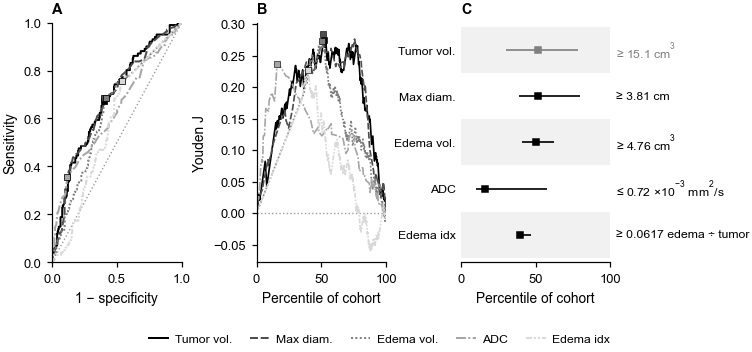

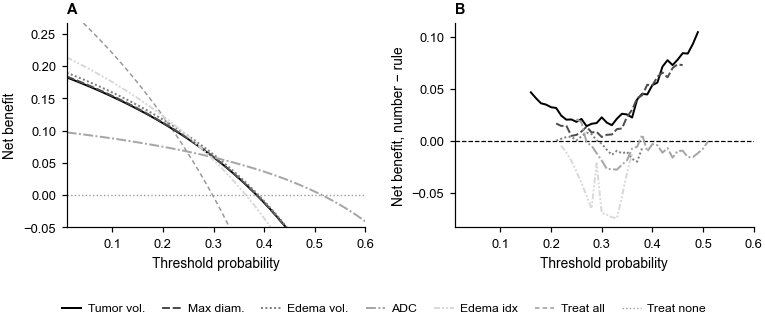

In [24]:
import outputs as op

RESULT = op.build(
    df, eligible=ELIGIBLE, cutpoints=FROZEN_CUTPOINTS, fits=FITS,
    separation=SEPARATION, nonlinearity=NONLINEARITY, wobble=WOBBLE,
    agreement=AGREEMENT, dichotomy=DICHOTOMY, imputation=IMPUTATION,
    segmented=SEGMENTED, presence=PRESENCE_AMOUNT,
    decision=DECISION, curves=CURVES, output_root=OUTPUT_ROOT)

print(op.describe(RESULT))